# Part 2: Vision Representation Learning

This notebook trains the phase-2 encoders on the Genesis/LeRobot pick-and-place dataset, compares the small CNN with ResNet-18, measures robustness shifts, and visualizes learned features.

In [1]:
import json
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from lerobot.datasets.lerobot_dataset import LeRobotDataset
import matplotlib.pyplot as plt

from part2_vision import (
    VisionAugmentation,
    SmallVisionEncoder,
    ResNet18VisionEncoder,
    make_vision_collate,
    train_vision_epoch,
    evaluate_vision,
    evaluate_robustness,
    extract_features,
    make_robustness_vision_collates,
    pca_2d,
    tsne_2d,
)

device = "cuda"

/home/haguruma/SourceCode/simple-vla/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Genesis/LeRobot Data

In [2]:
repo_id = "local/simple-vla-genesis-franka-pick-place"
root = Path("datasets/simple-vla-genesis-franka-pick-place")
info = json.loads((root / "meta" / "info.json").read_text())
episodes = list(range(info["total_episodes"]))
split = max(1, int(0.8 * len(episodes)))
train_episodes = episodes[:split]
eval_episodes = episodes[split:] or episodes[-1:]

train_ds = LeRobotDataset(repo_id=repo_id, root=root, episodes=train_episodes)
eval_ds = LeRobotDataset(repo_id=repo_id, root=root, episodes=eval_episodes)
vision_collate = make_vision_collate()

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, collate_fn=vision_collate)
eval_loader = DataLoader(eval_ds, batch_size=32, shuffle=False, num_workers=2, collate_fn=vision_collate)

batch = next(iter(train_loader))
batch["image"].shape, batch["label"].shape, batch["xy"].shape

(torch.Size([32, 3, 96, 96]), torch.Size([32]), torch.Size([32, 2]))

## Small CNN

In [3]:
small = SmallVisionEncoder().to(device)
optimizer = torch.optim.AdamW(small.parameters(), lr=3e-4, weight_decay=1e-4)

for epoch in range(10):
    train_metrics = train_vision_epoch(small, train_loader, optimizer, device=device)
    eval_metrics = evaluate_vision(small, eval_loader, device=device)
    print(epoch, train_metrics, eval_metrics)

pooled, patch_tokens = small.encode(batch["image"].to(device))
pooled.shape, patch_tokens.shape

0 VisionMetrics(loss=1.4187464714050293, class_loss=1.2137988408406575, xy_loss=0.020494758461912472, accuracy=0.0, xy_error=0.20245673755804697) VisionMetrics(loss=1.3962843815485637, class_loss=1.1981483300526936, xy_loss=0.019813607757290203, accuracy=0.0, xy_error=0.19906586408615112)
1 VisionMetrics(loss=1.3910868167877197, class_loss=1.1945313612620037, xy_loss=0.019655547415216763, accuracy=0.0, xy_error=0.19826703270276388) VisionMetrics(loss=1.3629361788431804, class_loss=1.1748237212498982, xy_loss=0.018811245759328205, accuracy=0.0, xy_error=0.19396516680717468)
2 VisionMetrics(loss=1.356107274691264, class_loss=1.1698787212371826, xy_loss=0.018622857828934986, accuracy=0.0, xy_error=0.19298646847407022) VisionMetrics(loss=1.3185133934020996, class_loss=1.1421053409576416, xy_loss=0.01764080176750819, accuracy=0.0, xy_error=0.18783393502235413)
3 VisionMetrics(loss=1.3091997702916462, class_loss=1.1350444952646892, xy_loss=0.0174155297378699, accuracy=0.0, xy_error=0.1866233

(torch.Size([32, 64]), torch.Size([32, 144, 64]))

## ResNet-18 Comparison

In [4]:
resnet = ResNet18VisionEncoder(feature_dim=128, pretrained=True).to(device)
optimizer = torch.optim.AdamW(resnet.parameters(), lr=1e-4, weight_decay=1e-4)

for epoch in range(5):
    train_metrics = train_vision_epoch(resnet, train_loader, optimizer, device=device)
    eval_metrics = evaluate_vision(resnet, eval_loader, device=device)
    print(epoch, train_metrics, eval_metrics)

0 VisionMetrics(loss=1.837741732597351, class_loss=1.1739782492319744, xy_loss=0.06637634709477425, accuracy=0.2916666666666667, xy_error=0.35844162106513977) VisionMetrics(loss=1.195721427599589, class_loss=0.7879042625427246, xy_loss=0.04078171898921331, accuracy=1.0, xy_error=0.28351126114527386)
1 VisionMetrics(loss=1.1643955707550049, class_loss=0.8238898118336996, xy_loss=0.03405057763059934, accuracy=0.8958333333333334, xy_error=0.254954715569814) VisionMetrics(loss=1.090398112932841, class_loss=0.8690192500750223, xy_loss=0.0221378846714894, accuracy=1.0, xy_error=0.20960559447606406)
2 VisionMetrics(loss=0.7204545537630717, class_loss=0.5797197620073954, xy_loss=0.014073477126657963, accuracy=1.0, xy_error=0.16277698675791422) VisionMetrics(loss=0.9943439563115438, class_loss=0.8529117703437805, xy_loss=0.014143217044572035, accuracy=0.8958333333333334, xy_error=0.166982372601827)
3 VisionMetrics(loss=0.4353354275226593, class_loss=0.3951076666514079, xy_loss=0.004022776304433

## Robustness Tests

In [5]:
robust_collates = make_robustness_vision_collates()
robust_loaders = {
    name: DataLoader(eval_ds, batch_size=32, shuffle=False, collate_fn=collate)
    for name, collate in robust_collates.items()
}
evaluate_robustness(small, robust_loaders, device=device)

{'train_distribution': VisionMetrics(loss=0.36612094442049664, class_loss=0.3564397990703583, xy_loss=0.0009681144341205558, accuracy=1.0, xy_error=0.04398958136638006),
 'lighting': VisionMetrics(loss=0.43328048785527545, class_loss=0.41314274072647095, xy_loss=0.0020137743558734655, accuracy=1.0, xy_error=0.05899286145965258),
 'background': VisionMetrics(loss=0.6733302076657613, class_loss=0.6216486096382141, xy_loss=0.005168161975840728, accuracy=1.0, xy_error=0.10166771213213603),
 'texture_noise': VisionMetrics(loss=0.1975508282581965, class_loss=0.18934186299641928, xy_loss=0.0008208958703714112, accuracy=1.0, xy_error=0.04051037132740021)}

## Data Augmentation

In [6]:
aug_ds = LeRobotDataset(repo_id=repo_id, root=root, episodes=train_episodes)
aug_collate = make_vision_collate(sample_transform=VisionAugmentation(image_size=96))
aug_loader = DataLoader(aug_ds, batch_size=32, shuffle=True, num_workers=2, collate_fn=aug_collate)

aug_model = SmallVisionEncoder().to(device)
optimizer = torch.optim.AdamW(aug_model.parameters(), lr=3e-4, weight_decay=1e-4)

for epoch in range(10):
    train_metrics = train_vision_epoch(aug_model, aug_loader, optimizer, device=device)
    robust_metrics = evaluate_robustness(aug_model, robust_loaders, device=device)
    print(epoch, train_metrics, robust_metrics)

0 VisionMetrics(loss=1.449199875195821, class_loss=1.166715939839681, xy_loss=0.028248388320207596, accuracy=0.0, xy_error=0.23768838246663412) {'train_distribution': VisionMetrics(loss=1.4314450025558472, class_loss=1.1558887958526611, xy_loss=0.02755562588572502, accuracy=0.0, xy_error=0.23475786050160727), 'lighting': VisionMetrics(loss=1.4312272866566975, class_loss=1.1558878024419148, xy_loss=0.027533953388532, accuracy=0.0, xy_error=0.23466473817825317), 'background': VisionMetrics(loss=1.4335486888885498, class_loss=1.1552246411641438, xy_loss=0.027832405641674995, accuracy=0.0, xy_error=0.23593390981356302), 'texture_noise': VisionMetrics(loss=1.4291373491287231, class_loss=1.1561315059661865, xy_loss=0.027300589407483738, accuracy=0.0, xy_error=0.2336689531803131)}
1 VisionMetrics(loss=1.427203893661499, class_loss=1.1535106897354126, xy_loss=0.027369319771726925, accuracy=0.0, xy_error=0.233960231145223) {'train_distribution': VisionMetrics(loss=1.4074133237202961, class_loss

## Feature Visualization

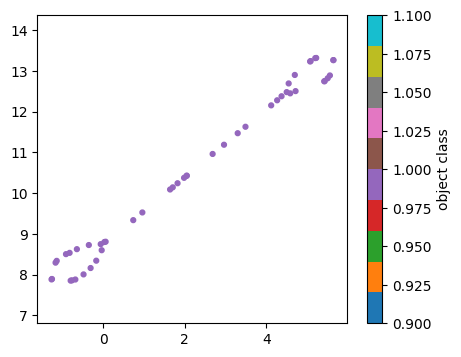

In [7]:
features = extract_features(small, eval_loader, device=device, feature="pooled")
embedding = tsne_2d(features["feature"], perplexity=20)
# embedding = pca_2d(features["feature"])

plt.figure(figsize=(5, 4))
plt.scatter(embedding[:, 0], embedding[:, 1], c=features["label"], cmap="tab10", s=12)
plt.colorbar(label="object class")
plt.axis("equal");